# Data prep illustration


In [4]:
import os

import astropy.io.fits as pyfits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx

meta = MetaData()

# Custom functions

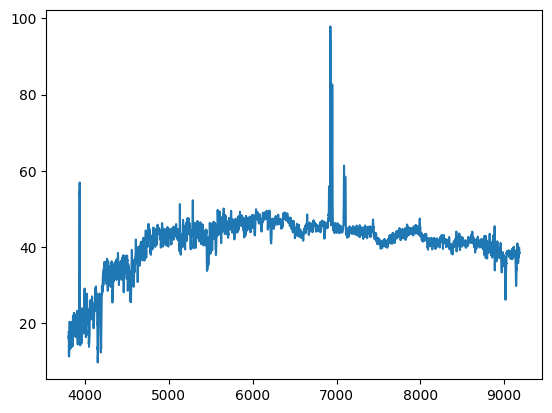

In [ ]:
def get_data_from_fits_file(file_path):
    """
    Get flux, sky, wave and ivar from a SDSS fits file.
    The fits file come from spec lite version of SDSS
    data reduction pipeline.
    """

    with pyfits.open(file_path, memmap=False) as hdul:
        # Get the data from HDU 1 (COADD)
        data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    sky = data['SKY']
    ivar = data['ivar']

    return flux, sky, wavelength, ivar

file_location = f'{fits_files_dir}/spec-2636-54082-0164.fits'
    

# Directories

In [3]:
thesis_dir = "/home/elom/gdrive/career/portfolio/phd/thesis_phd"
ch_3_dir = f"{thesis_dir}/chapters/03_figures"

data_dir = "/home/elom/phd/code_phd/spectra"
fits_files_dir = f"{data_dir}/fits_files_illustrations"
bin_id = "bin_03"

# Data ingestion

In [3]:
wave = np.load(f"{data_dir}/wave_spectra_imputed.npy")
# convert from Angstroms to nanometers
wave = wave / 10.0

spectra = np.load(
    f"{data_dir}/spectra_imputed.npy",
    mmap_mode="r"
)
idx_id_bin_03 = np.load(
    f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)

In [4]:
drop_meta_data_df = pd.read_csv(
    f"{data_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

bin_03_df = drop_meta_data_df.loc[idx_id_bin_03[:, 1]].copy()

## Fits file

In [33]:
import astropy.io.fits as pyfits
import numpy as np
import pandas as pd

from sdss.utils.managefiles import FileDirectory
from sdss.metadata import MetaData

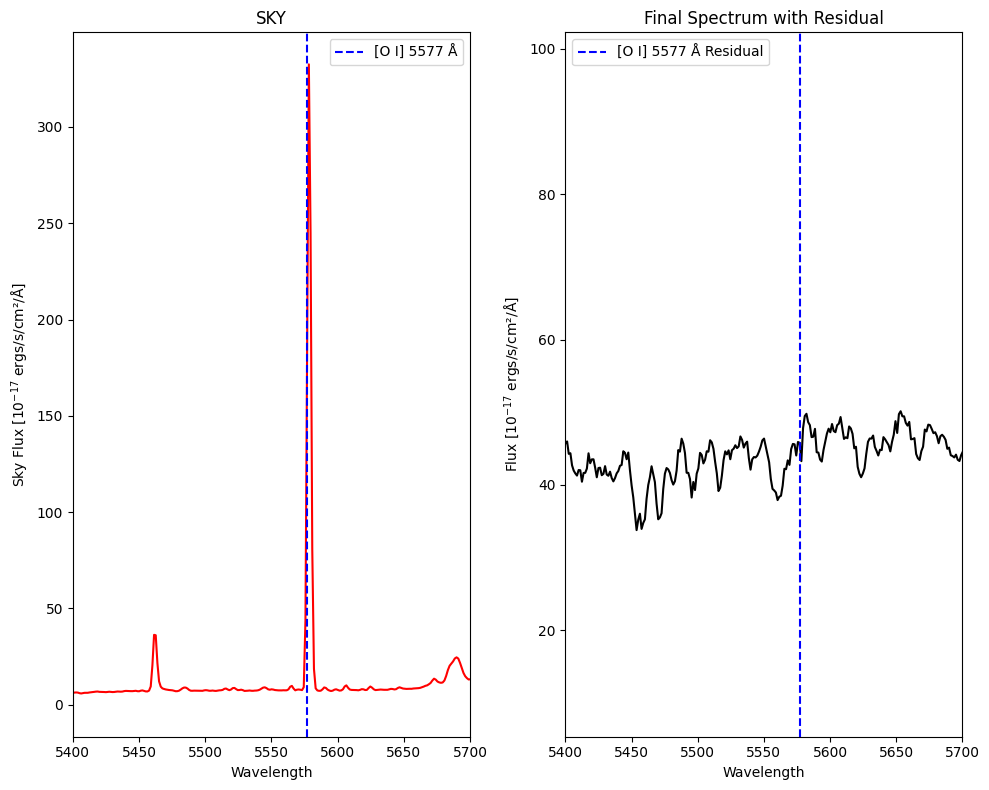

In [44]:
file_location = '/home/elom/gdrive/career/portfolio/phd/thesis_phd/chapters/03_figures'
fname = 'spec-2636-54082-0164.fits'

hdul = pyfits.open(
    f"{file_location}/{fname}",
    memmap=False
)


# Get the data from HDU 1 (COADD)
data = hdul[1].data
wavelength = 10**data['loglam']

sky_flux = data['SKY']
science_flux = data['flux']
hdul.close()

# --- Create the Figure ---
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 8)
)

# SKY spectrum
ax1.plot(wavelength, sky_flux, 'r-')
ax1.set_title("SKY")
ax1.set_xlabel("Wavelength")
ax1.set_ylabel("Sky Flux [$10^{-17}$ ergs/s/cm²/Å]")
# Highlight the line
ax1.axvline(5577, color='blue', linestyle='--', label='[O I] 5577 Å')
ax1.legend()
ax1.set_xlim(5400, 5700) # Zoom in on the region of interest

# # Panel 2: Plot the SCIENCE spectrum (use a passive galaxy!)
# # NOTE: This spectrum is in the OBSERVED frame.
# # You will need to plot this *before* your rest-framing step.
ax2.plot(wavelength, science_flux, 'k-')
ax2.set_title("Final Spectrum with Residual")
ax2.set_xlabel("Wavelength")
ax2.set_ylabel("Flux [$10^{-17}$ ergs/s/cm²/Å]")
# Highlight the residual
ax2.axvline(5577, color='blue', linestyle='--', label='[O I] 5577 Å Residual')
ax2.legend()
ax2.set_xlim(5400, 5700) # Zoom in on the same region

plt.tight_layout()
plt.show()

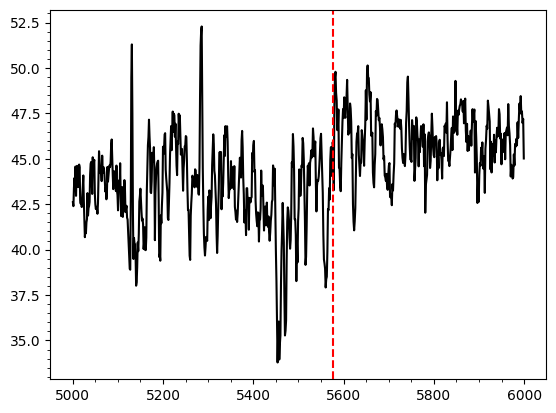

In [39]:
file_location = '/home/elom/gdrive/career/portfolio/phd/thesis_phd/chapters/03_figures'
fname = 'spec-2636-54082-0164.fits'

hdul = pyfits.open(
    f"{file_location}/{fname}",
    memmap=False
)

wave_raw = np.array(10.0 ** (hdul[1].data["loglam"]), dtype=float)
flux_raw = hdul[1].data["flux"]
ivar_raw = hdul[1].data["ivar"]
specobjid = int(hdul[2].data["specobjid"].item())

hdul.close()
wave_mask = (wave_raw >= 5000) & (wave_raw <= 6000)
fig, ax = plt.subplots()
# ax.plot(wave_raw, flux_raw, color='black')
ax.plot(wave_raw[wave_mask], flux_raw[wave_mask], color='black')
ax.minorticks_on()

# add horizontal line in x = 5557
ax.axvline(x=5577, color='red', linestyle='--')


## Passive

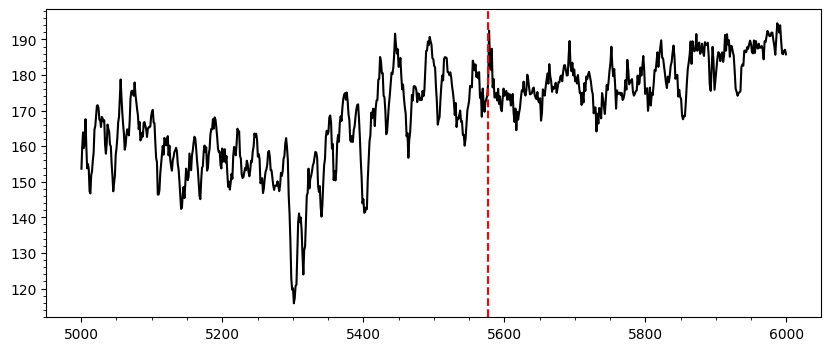

In [ ]:
file_location = '/home/elom/gdrive/career/portfolio/phd/thesis_phd/chapters/03_figures'
fname = 'spec-1587-52964-0435.fits'

hdul = pyfits.open(
    f"{file_location}/{fname}",
    memmap=False
)

wave_raw = np.array(10.0 ** (hdul[1].data["loglam"]), dtype=float)
flux_raw = hdul[1].data["flux"]
ivar_raw = hdul[1].data["ivar"]
specobjid = int(hdul[2].data["specobjid"].item())

hdul.close()
wave_mask = (wave_raw >= 5000) & (wave_raw <= 6000)
fig, ax = plt.subplots(
    figsize=(10, 4)
)
# ax.plot(wave_raw, flux_raw, color='black')
ax.plot(wave_raw[wave_mask], flux_raw[wave_mask], color='black')
ax.minorticks_on()

# add horizontal line in x = 5557
ax.axvline(x=5577, color='red', linestyle='--')
sas/dr16/sdss/spectro/redux

# Ignore

# Passive Galaxy
a passive galaxy with a red continuum and strong absorption features like the 400 nm break, 

# Manuscript plots

# Passive Galaxy

In [85]:
obj_id = 1786922773776459776
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
passive_spec = spectra[idx_spec]

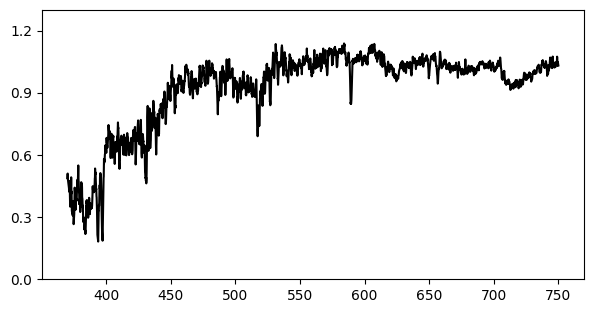

In [82]:
obj_id = 1786922773776459776
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

# Load the image
# image_name = 'passive_photo_1786922773776459776.jpeg'
# image_path = f"{chapter_1_specs_dir}/{image_name}"
# photo_img = mpimg.imread(image_path)

fig, ax = plt.subplots(
    figsize=(7, 3.5)
)
ax, axins = spec_photo_thumbnail(
    ax,
    wave,spec,
    # photo_img=photo_img,
    width_height_image='100%',
    bbox_to_anchor=(0.775,0.055,0.3,0.3),
    add_image=False,
)
ax.set_ylim(-0, 1.3) 
ticks = [0, 0.3, 0.6, 0.9, 1.2]
ax.set_yticks(ticks)

fig.savefig(
    f"{ch_1_dir}/passive_sample.pdf",
    bbox_inches='tight'
)

# Starforming and Starburst

## Data

In [53]:
# Spectra
# sf 1
sf_1_objid = 577752436958062592
sf_1_idx_spec = specobjid_to_idx(sf_1_objid, idx_id_bin_03)
sf_1_spec = spectra[sf_1_idx_spec]
# sf 2
sf_2_objid = 439212870853486592
sf_2_idx_spec = specobjid_to_idx(sf_2_objid, idx_id_bin_03)
sf_2_spec = spectra[sf_2_idx_spec]
# sb 1
sb_1_objid = 2169743591499393024
sb_1_idx_spec = specobjid_to_idx(sb_1_objid, idx_id_bin_03)
sb_1_spec = spectra[sb_1_idx_spec]
# sb 2
sb_2_objid = 737558208620554240
sb_2_idx_spec = specobjid_to_idx(sb_2_objid, idx_id_bin_03)
sb_2_spec = spectra[sb_2_idx_spec]
# ---------------------------------------------------------------------
# # Images
# image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
# # sf_1
# sf_1_image_name = f'sf_1_image_{sf_1_objid}.jpeg'
# sf_1_img = mpimg.imread(f"{image_dir}/{sf_1_image_name}")
# # sf_2
# sf_2_image_name = f'sf_2_image_{sf_2_objid}.jpeg'
# sf_2_img = mpimg.imread(f"{image_dir}/{sf_2_image_name}")
# # sb_1
# sb_1_image_name = f'sb_1_image_{sb_1_objid}.jpeg'
# sb_1_img = mpimg.imread(f"{image_dir}/{sb_1_image_name}")
# # sb_2
# sb_2_image_name = f'sb_2_image_{sb_2_objid}.jpeg'
# sb_2_img = mpimg.imread(f"{image_dir}/{sb_2_image_name}")



## Passive + SF

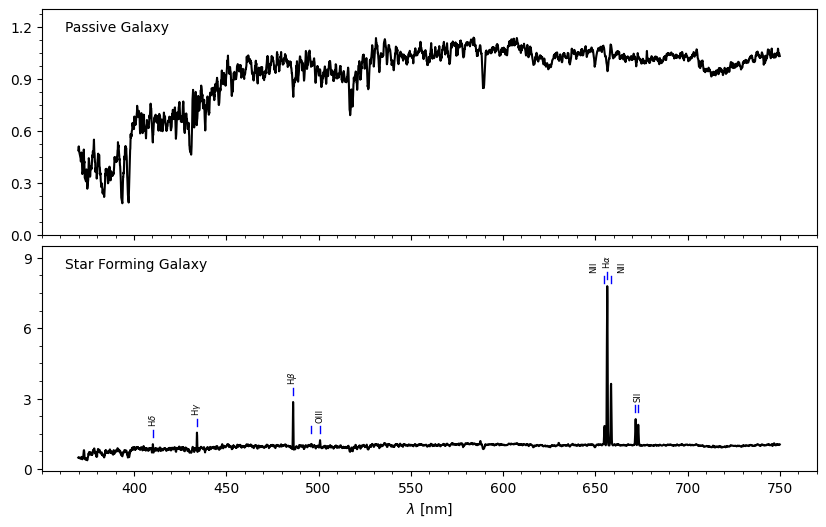

In [95]:
figsize = (10, 6)

fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    figsize=figsize
)
# -------------------------------------------------
axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, passive_spec,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Passive Galaxy', 
    transform=axs[0].transAxes, 
    verticalalignment='top', 
)
# 
axs[0].set_ylim(-0, 1.3) 
passive_ticks = [0, 0.3, 0.6, 0.9, 1.2]
axs[0].set_yticks(passive_ticks)

# ---------------------------------------------- 
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, sf_1_spec,
    add_image=False,
)
axs[1].text(
    0.03, 0.95,
    f'Star Forming Galaxy', 
    transform=axs[1].transAxes, 
    verticalalignment='top', 
)
# 
axs[1].set_ylim(-0.1, 9.5) 
sf_1_ticks = [0, 3, 6, 9]
axs[1].set_yticks(sf_1_ticks)

axs[1] = add_line_indicators(
    axs[1], wave, sf_1_spec,
    delta=4,
    indicator_starts=0.3,
    indicator_height=0.3,
    add_ne3_he1=False,
    add_h_epsilon=False,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# ---------------------------------------------- 

axs[1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
)

fig.savefig(
    f"{ch_1_dir}/passive_sf_samples.pdf",
    bbox_inches='tight'
)